# Домашняя работа 8

Импортируем нужные библиотеки

In [15]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms

print("torch", torch.__version__)
print("torchvision:", torchvision.__version__)


torch 2.10.0+cu130
torchvision: 0.25.0+cu130


Фиксируем seed

In [16]:
def set_seed(seed: int=42) ->None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:",device)

device: cuda


Подготавливаем функции, которые пригодятся в будущем

In [17]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def plot_history(history: dict, title: str = "", save: str = None) -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))

    ax1.plot(epochs, history["train_loss"], label="train_loss")
    ax1.plot(epochs, history["val_loss"], label="val_loss")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("loss")
    ax1.set_title((title + " (loss)") if title else "loss")
    ax1.legend()
    ax1.grid(True)


    ax2.plot(epochs, history["train_acc"], label="train_acc")
    ax2.plot(epochs, history["val_acc"], label="val_acc")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("accuracy")
    ax2.set_title((title + " (accuracy)") if title else "accuracy")
    ax2.legend()
    ax2.grid(True)

    if save:
        plt.savefig(save,dpi=300,bbox_inches="tight")
    
    plt.tight_layout()
    plt.show()

Импортируем датасет Emnist

In [18]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)),
])

train_full = torchvision.datasets.EMNIST(
    split="balanced",root="./data",train=True,
    download=True,transform=transform)

test_ds = torchvision.datasets.EMNIST(
    split="balanced",root="./data",train=False,
    download=True,transform=transform)

class_names = train_full.classes
print("classes:", class_names)
print("num_classes:",len(class_names))
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
num_classes: 47
train size: 112800
test size: 18800


Настраиваем batch_size и создаем loader-ы 

In [19]:
BATCH_SIZE = 256 if device.type == "cuda" else 64

NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.1
val_size = int(len(train_full)* val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)

train_ds, val_ds = random_split(train_full, [train_size,val_size],generator=gen)

train_loader = DataLoader(
    train_ds,batch_size=BATCH_SIZE,shuffle=True,
    num_workers=NUM_WORKERS,pin_memory=(device.type=="cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

In [20]:
x_batch, y_batch = next(iter(train_loader))
print("x_batch:",x_batch.shape,x_batch.dtype)
print("y_batch:",y_batch.shape,y_batch.dtype)

x_batch: torch.Size([256, 1, 28, 28]) torch.float32
y_batch: torch.Size([256]) torch.int64


Покажем пример 10 картинок из датасета

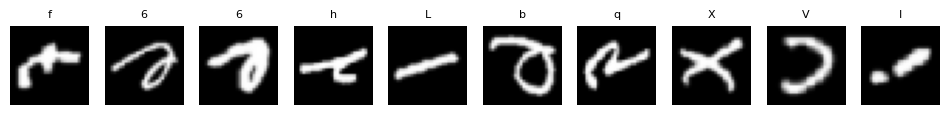

In [21]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)

        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

## MLP

Создаем класс многослойного персептрона

In [22]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28*28,
        hidden_dims: tuple = (256,128),
        num_classes: int= 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()
        act = activation.lower()
        if act =="relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]
        
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev,h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p = dropout_p))
            prev = h
        
        layers.append(nn.Linear(prev,num_classes))
        self.net = nn.Sequential(*layers)
    
    def forward(self,x):
        return self.net(x)
    

model = MLP(dropout_p=0.2,use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([256, 47])


Создаем функцию обучения одной эпохой и подсчета метрик

In [23]:
def train_one_epoch(model,loader,optimizer,criterion,device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x,y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits,y)

        loss.backward()
        optimizer.step()

        total_loss+= loss.item()
        total_acc+= accuracy_from_logits(logits,y)
        n_batches+= 1

    return total_loss/ n_batches, total_acc/n_batches


@torch.no_grad()
def evaluate(model,loader,criterion,device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x,y in loader:
        x = x.to(device,non_blocking = True)
        y = y.to(device,non_blocking = True)

        logits = model(x)
        loss = criterion(logits,y)

        total_loss+= loss.item()
        total_acc+= accuracy_from_logits(logits,y)
        n_batches+= 1

    return total_loss/ n_batches, total_acc/n_batches

Создаем класс для EarlyStopping

In [24]:
class EarlyStopping:
    def __init__(self,patience: int=5,min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self,score: float,model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
            return False
        
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience
    
    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

Создаем функцию полного обучения модели

In [25]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs : int = 20,
    early_stopping = None,
    verbose: bool = True,
):
    history = {"train_loss":[],"val_loss":[], "train_acc": [],"val_acc":[]}
    for epoch in range(1,epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss= {tr_loss:.4f},acc={tr_acc:.4f} | "
                f"val loss = {va_loss:.4f}, acc={va_acc:.4f}"
            )
        
        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc,model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break
        
    return history

EX0 (Baseline)

epoch 01/20 | train loss= 1.5090,acc=0.5894 | val loss = 1.1277, acc=0.6831
epoch 02/20 | train loss= 1.0135,acc=0.7079 | val loss = 0.9373, acc=0.7292
epoch 03/20 | train loss= 0.8409,acc=0.7517 | val loss = 0.8042, acc=0.7692
epoch 04/20 | train loss= 0.7361,acc=0.7777 | val loss = 0.7339, acc=0.7771
epoch 05/20 | train loss= 0.6769,acc=0.7916 | val loss = 0.6919, acc=0.7875
epoch 06/20 | train loss= 0.6321,acc=0.8028 | val loss = 0.6490, acc=0.8053
epoch 07/20 | train loss= 0.5977,acc=0.8117 | val loss = 0.6336, acc=0.8045
epoch 08/20 | train loss= 0.5726,acc=0.8178 | val loss = 0.6202, acc=0.8144
epoch 09/20 | train loss= 0.5505,acc=0.8217 | val loss = 0.5987, acc=0.8172
epoch 10/20 | train loss= 0.5312,acc=0.8284 | val loss = 0.5787, acc=0.8226
epoch 11/20 | train loss= 0.5189,acc=0.8309 | val loss = 0.5786, acc=0.8241
epoch 12/20 | train loss= 0.5078,acc=0.8338 | val loss = 0.5838, acc=0.8161
epoch 13/20 | train loss= 0.4965,acc=0.8357 | val loss = 0.5705, acc=0.8155
epoch 14/20 

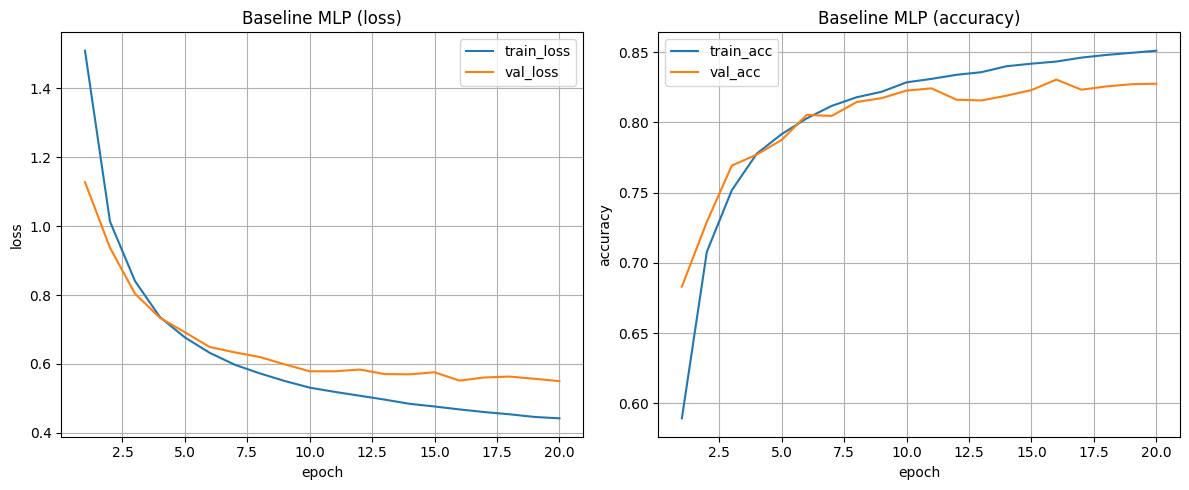

Baseline test: loss=0.5851, acc=0.8150


In [26]:
set_seed(42)
baseline = MLP(hidden_dims=(128,),dropout_p=0.0,use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(),lr=1e-3)

history_baseline = fit(
    baseline,train_loader,val_loader,
    optimizer,criterion,device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline,title ="Baseline MLP")
test_loss, test_acc = evaluate(baseline, test_loader, criterion, device)
print(f"Baseline test: loss={test_loss:.4f}, acc={test_acc:.4f}")

EX1 (Baseline deeper and wider)

epoch 01/20 | train loss= 1.4201,acc=0.6038 | val loss = 0.9649, acc=0.7109
epoch 02/20 | train loss= 0.8011,acc=0.7556 | val loss = 0.7266, acc=0.7720
epoch 03/20 | train loss= 0.6381,acc=0.7975 | val loss = 0.6123, acc=0.8097
epoch 04/20 | train loss= 0.5626,acc=0.8165 | val loss = 0.5745, acc=0.8193
epoch 05/20 | train loss= 0.5138,acc=0.8308 | val loss = 0.5305, acc=0.8302
epoch 06/20 | train loss= 0.4805,acc=0.8381 | val loss = 0.5415, acc=0.8281
epoch 07/20 | train loss= 0.4530,acc=0.8452 | val loss = 0.5260, acc=0.8288
epoch 08/20 | train loss= 0.4333,acc=0.8509 | val loss = 0.4990, acc=0.8386
epoch 09/20 | train loss= 0.4127,acc=0.8550 | val loss = 0.4853, acc=0.8411
epoch 10/20 | train loss= 0.3940,acc=0.8625 | val loss = 0.4961, acc=0.8387
epoch 11/20 | train loss= 0.3805,acc=0.8639 | val loss = 0.4828, acc=0.8456
epoch 12/20 | train loss= 0.3684,acc=0.8690 | val loss = 0.4980, acc=0.8378
epoch 13/20 | train loss= 0.3565,acc=0.8710 | val loss = 0.4890, acc=0.8352
epoch 14/20 

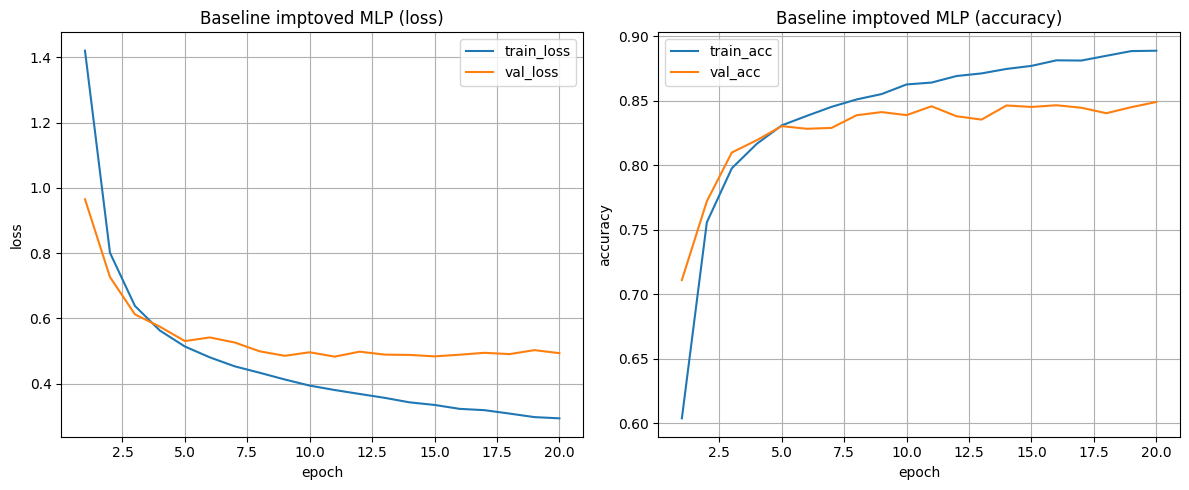

Baseline improved test: loss=0.5247, acc=0.8416


In [27]:
set_seed(42)
baseline_improved = MLP(hidden_dims=(256,128),dropout_p=0.0,use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_improved.parameters(),lr=1e-3)

history_baseline_improved = fit(
    baseline_improved,train_loader,val_loader,
    optimizer,criterion,device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline_improved,title ="Baseline imptoved MLP")
test_loss, test_acc = evaluate(baseline_improved, test_loader, criterion, device)
print(f"Baseline improved test: loss={test_loss:.4f}, acc={test_acc:.4f}")

EX2 (Dropout)

epoch 01/20 | train loss= 1.7599,acc=0.4997 | val loss = 0.9789, acc=0.7074
epoch 02/20 | train loss= 1.1032,acc=0.6663 | val loss = 0.7729, acc=0.7602
epoch 03/20 | train loss= 0.9579,acc=0.7052 | val loss = 0.6937, acc=0.7862
epoch 04/20 | train loss= 0.8823,acc=0.7250 | val loss = 0.6455, acc=0.8010
epoch 05/20 | train loss= 0.8387,acc=0.7352 | val loss = 0.6198, acc=0.8062
epoch 06/20 | train loss= 0.7973,acc=0.7477 | val loss = 0.5868, acc=0.8089
epoch 07/20 | train loss= 0.7723,acc=0.7539 | val loss = 0.5789, acc=0.8125
epoch 08/20 | train loss= 0.7536,acc=0.7580 | val loss = 0.5605, acc=0.8158
epoch 09/20 | train loss= 0.7404,acc=0.7607 | val loss = 0.5416, acc=0.8260
epoch 10/20 | train loss= 0.7226,acc=0.7679 | val loss = 0.5353, acc=0.8242
epoch 11/20 | train loss= 0.7102,acc=0.7693 | val loss = 0.5298, acc=0.8230
epoch 12/20 | train loss= 0.7042,acc=0.7715 | val loss = 0.5177, acc=0.8303
epoch 13/20 | train loss= 0.6983,acc=0.7747 | val loss = 0.5202, acc=0.8299
epoch 14/20 

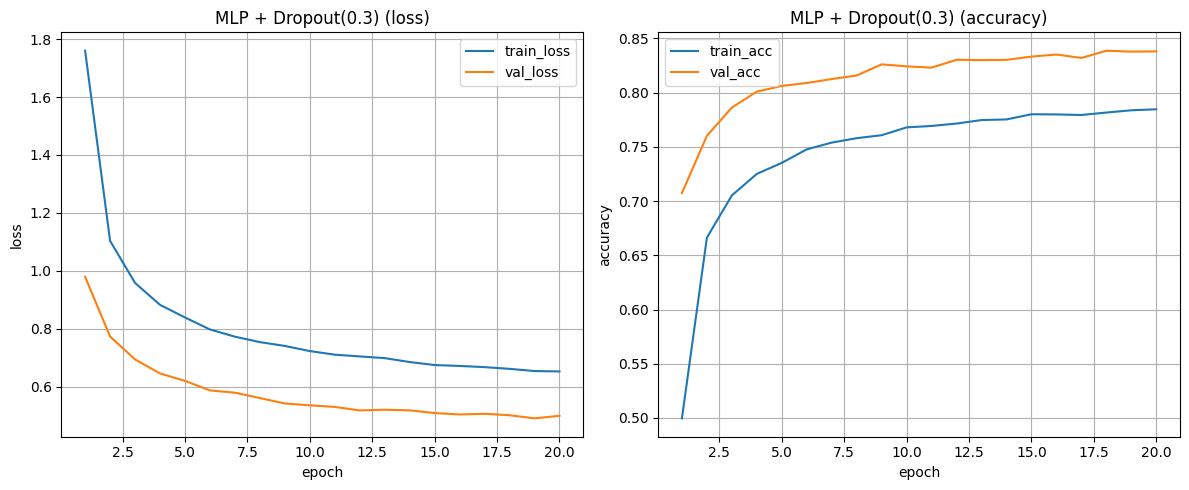

Dropout test: loss=0.5192, acc=0.8271


In [28]:
set_seed(42)
dropout_model = MLP(hidden_dims=(256,128),dropout_p=0.3,use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(),lr=1e-3)

history_dropout = fit(
    dropout_model,train_loader, val_loader,
    optimizer,criterion,device,
    epochs = 20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")

EX3 (BatchNorm)

epoch 01/20 | train loss= 1.0893,acc=0.7206 | val loss = 0.6338, acc=0.8060
epoch 02/20 | train loss= 0.5319,acc=0.8276 | val loss = 0.5288, acc=0.8256
epoch 03/20 | train loss= 0.4433,acc=0.8502 | val loss = 0.4820, acc=0.8396
epoch 04/20 | train loss= 0.3933,acc=0.8641 | val loss = 0.4648, acc=0.8458
epoch 05/20 | train loss= 0.3616,acc=0.8717 | val loss = 0.4867, acc=0.8365
epoch 06/20 | train loss= 0.3341,acc=0.8804 | val loss = 0.4572, acc=0.8475
epoch 07/20 | train loss= 0.3138,acc=0.8852 | val loss = 0.4658, acc=0.8439
epoch 08/20 | train loss= 0.2960,acc=0.8908 | val loss = 0.4556, acc=0.8469
epoch 09/20 | train loss= 0.2779,acc=0.8963 | val loss = 0.4645, acc=0.8491
epoch 10/20 | train loss= 0.2677,acc=0.8983 | val loss = 0.4653, acc=0.8503
epoch 11/20 | train loss= 0.2530,acc=0.9039 | val loss = 0.4758, acc=0.8455
epoch 12/20 | train loss= 0.2417,acc=0.9074 | val loss = 0.4783, acc=0.8485
epoch 13/20 | train loss= 0.2314,acc=0.9100 | val loss = 0.5064, acc=0.8411
epoch 14/20 

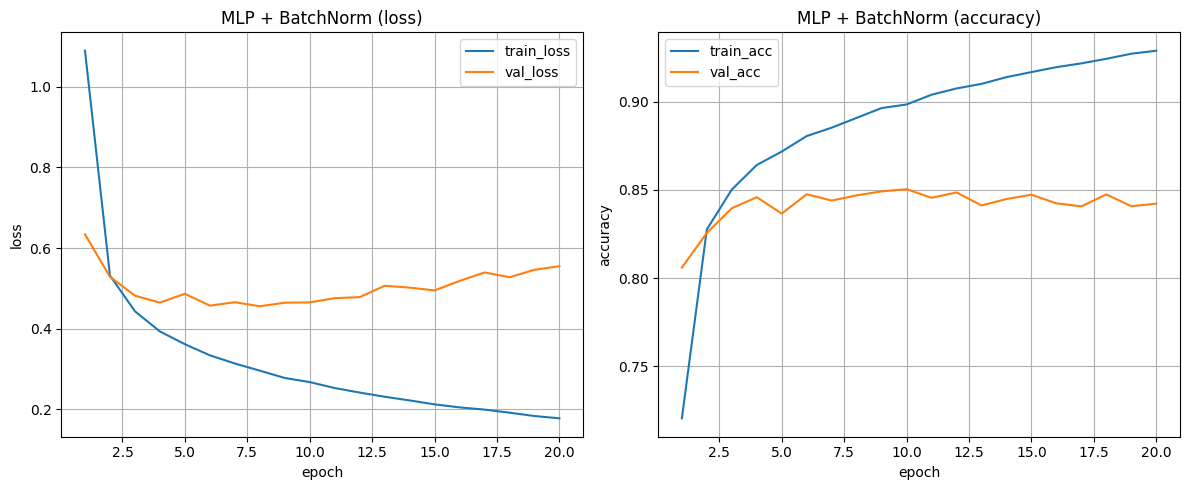

BatchNorm test: loss=0.5581, acc=0.8419


In [29]:
set_seed(42)
bn_model = MLP(hidden_dims=(256,128),dropout_p=0.0,use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(),lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")
test_loss, test_acc = evaluate(bn_model, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

EX4 (BatchNorm + EarlyStopping)

epoch 01/50 | train loss= 1.0893,acc=0.7206 | val loss = 0.6338, acc=0.8060
epoch 02/50 | train loss= 0.5319,acc=0.8276 | val loss = 0.5288, acc=0.8256
epoch 03/50 | train loss= 0.4433,acc=0.8502 | val loss = 0.4820, acc=0.8396
epoch 04/50 | train loss= 0.3933,acc=0.8641 | val loss = 0.4648, acc=0.8458
epoch 05/50 | train loss= 0.3616,acc=0.8717 | val loss = 0.4867, acc=0.8365
epoch 06/50 | train loss= 0.3341,acc=0.8804 | val loss = 0.4572, acc=0.8475
epoch 07/50 | train loss= 0.3138,acc=0.8852 | val loss = 0.4658, acc=0.8439
epoch 08/50 | train loss= 0.2960,acc=0.8908 | val loss = 0.4556, acc=0.8469
epoch 09/50 | train loss= 0.2779,acc=0.8963 | val loss = 0.4645, acc=0.8491
epoch 10/50 | train loss= 0.2677,acc=0.8983 | val loss = 0.4653, acc=0.8503
epoch 11/50 | train loss= 0.2530,acc=0.9039 | val loss = 0.4758, acc=0.8455
epoch 12/50 | train loss= 0.2417,acc=0.9074 | val loss = 0.4783, acc=0.8485
epoch 13/50 | train loss= 0.2314,acc=0.9100 | val loss = 0.5064, acc=0.8411
epoch 14/50 

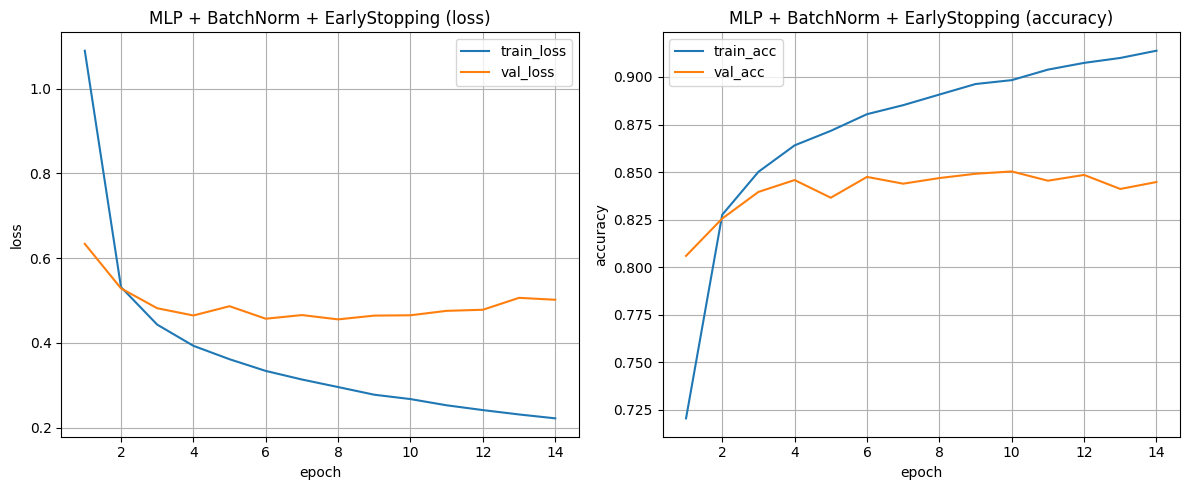

Combo test: loss=0.4856, acc=0.8458


In [30]:
set_seed(42)
combo_model = MLP(hidden_dims=(256,128),dropout_p=0.0,use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(),lr=1e-3)

es = EarlyStopping(patience=4,min_delta = 0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,
    early_stopping=es,
    verbose=True
)

plot_history(history_combo, title="MLP + BatchNorm + EarlyStopping",save="artifacts/figures/curves_best.png")
E4_test_loss, E4_test_acc = evaluate(combo_model, test_loader, criterion, device)
print(f"Combo test: loss={E4_test_loss:.4f}, acc={E4_test_acc:.4f}")

Мини-сравнение результатов

In [31]:
results = {
    "baseline": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)[1],
    "baseline improved": evaluate(baseline_improved, test_loader, nn.CrossEntropyLoss(), device)[1],
    "dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "batchnorm": evaluate(bn_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "combo": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

 baseline: test_acc=0.8150
baseline improved: test_acc=0.8416
  dropout: test_acc=0.8271
batchnorm: test_acc=0.8419
    combo: test_acc=0.8458


O1 (LR слишком большой)

epoch 01/8 | train loss= 1.0090,acc=0.6933 | val loss = 0.7622, acc=0.7593
epoch 02/8 | train loss= 0.6835,acc=0.7776 | val loss = 0.6678, acc=0.7859
epoch 03/8 | train loss= 0.6139,acc=0.7972 | val loss = 0.6470, acc=0.7947
epoch 04/8 | train loss= 0.5762,acc=0.8051 | val loss = 0.6480, acc=0.7945
epoch 05/8 | train loss= 0.5476,acc=0.8156 | val loss = 0.6266, acc=0.8056
epoch 06/8 | train loss= 0.5250,acc=0.8198 | val loss = 0.5778, acc=0.8166
epoch 07/8 | train loss= 0.4984,acc=0.8293 | val loss = 0.5766, acc=0.8183
epoch 08/8 | train loss= 0.4966,acc=0.8295 | val loss = 0.6068, acc=0.8084


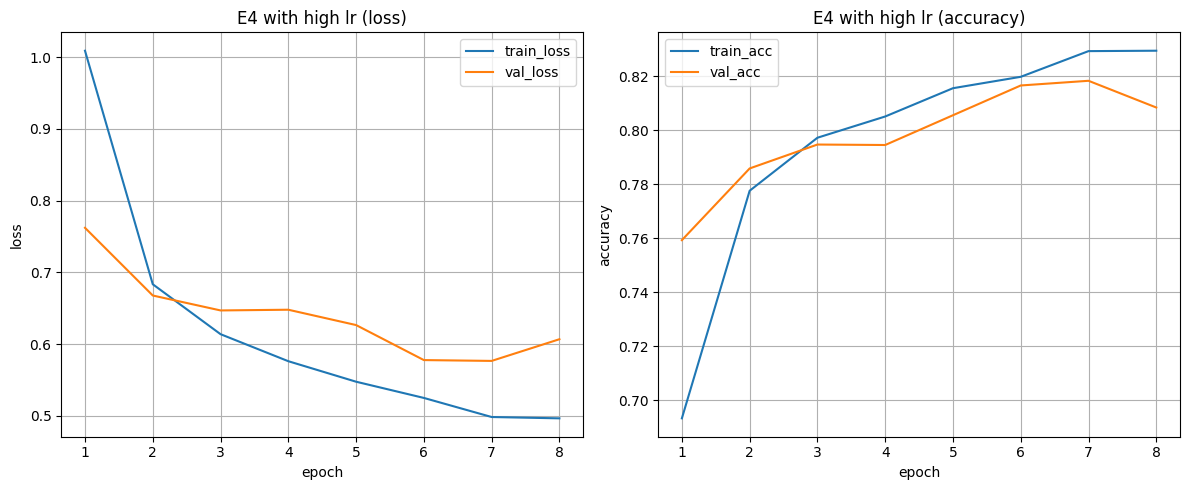

High lr test: loss=0.6372, acc=0.8033


In [32]:
set_seed(42)
combo_o1_model = MLP(hidden_dims=(256,128),dropout_p=0.0,use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_o1_model.parameters(),lr=1e-1)

es = EarlyStopping(patience=4,min_delta = 0.0005)

history_combo_o1 = fit(
    combo_o1_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=es,
    verbose=True
)

plot_history(history_combo_o1, title="E4 with high lr",save="artifacts/figures/curves_lr_extremes_O1.png")
test_loss, test_acc = evaluate(combo_o1_model, test_loader, criterion, device)
print(f"High lr test: loss={test_loss:.4f}, acc={test_acc:.4f}")

O2 (LR слишком маленький)

epoch 01/8 | train loss= 3.5897,acc=0.1204 | val loss = 3.2960, acc=0.2350
epoch 02/8 | train loss= 3.1011,acc=0.3256 | val loss = 2.9295, acc=0.3987
epoch 03/8 | train loss= 2.8038,acc=0.4451 | val loss = 2.6853, acc=0.4839
epoch 04/8 | train loss= 2.5855,acc=0.5118 | val loss = 2.4952, acc=0.5317
epoch 05/8 | train loss= 2.4079,acc=0.5558 | val loss = 2.3292, acc=0.5714
epoch 06/8 | train loss= 2.2543,acc=0.5868 | val loss = 2.1899, acc=0.5993
epoch 07/8 | train loss= 2.1185,acc=0.6096 | val loss = 2.0626, acc=0.6213
epoch 08/8 | train loss= 1.9962,acc=0.6292 | val loss = 1.9429, acc=0.6352


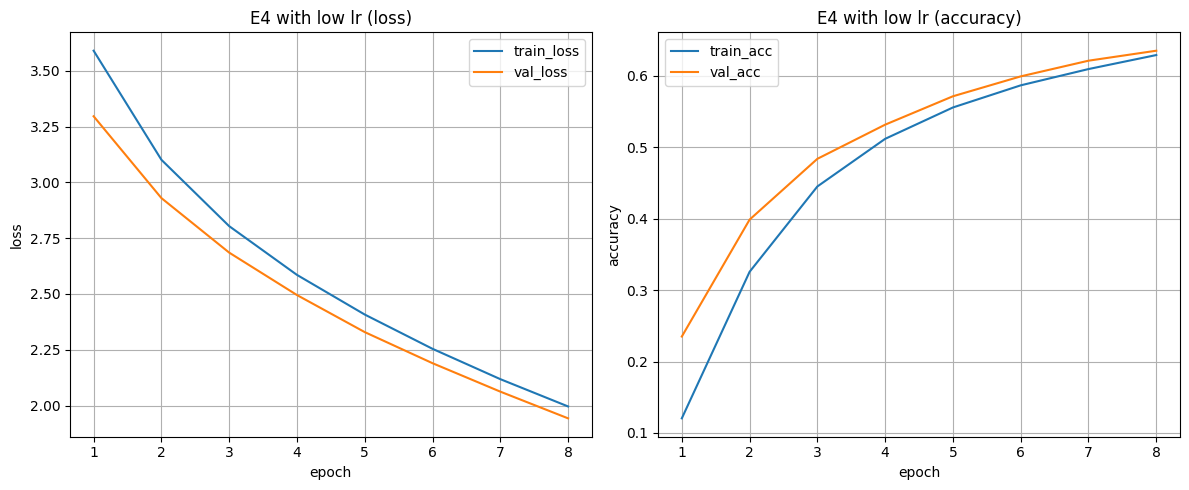

Low lr test: loss=1.9460, acc=0.6316


In [33]:
set_seed(42)
combo_o2_model = MLP(hidden_dims=(256,128),dropout_p=0.0,use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_o2_model.parameters(),lr=1e-5)

es = EarlyStopping(patience=4,min_delta = 0.0005)

history_combo_o2 = fit(
    combo_o2_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=es,
    verbose=True
)

plot_history(history_combo_o2, title="E4 with low lr",save="artifacts/figures/curves_lr_extremes_O2.png")
test_loss, test_acc = evaluate(combo_o2_model, test_loader, criterion, device)
print(f"Low lr test: loss={test_loss:.4f}, acc={test_acc:.4f}")

O3 (SGD+momentum + weight decay)

epoch 01/15 | train loss= 2.8245,acc=0.3936 | val loss = 2.1563, acc=0.5651
epoch 02/15 | train loss= 1.8085,acc=0.6192 | val loss = 1.5283, acc=0.6569
epoch 03/15 | train loss= 1.3529,acc=0.6846 | val loss = 1.2108, acc=0.7088
epoch 04/15 | train loss= 1.1039,acc=0.7256 | val loss = 1.0252, acc=0.7391
epoch 05/15 | train loss= 0.9497,acc=0.7520 | val loss = 0.9012, acc=0.7637
epoch 06/15 | train loss= 0.8429,acc=0.7719 | val loss = 0.8146, acc=0.7815
epoch 07/15 | train loss= 0.7651,acc=0.7877 | val loss = 0.7522, acc=0.7931
epoch 08/15 | train loss= 0.7063,acc=0.8007 | val loss = 0.7029, acc=0.8045
epoch 09/15 | train loss= 0.6595,acc=0.8103 | val loss = 0.6672, acc=0.8101
epoch 10/15 | train loss= 0.6215,acc=0.8182 | val loss = 0.6375, acc=0.8169
epoch 11/15 | train loss= 0.5903,acc=0.8254 | val loss = 0.6136, acc=0.8220
epoch 12/15 | train loss= 0.5639,acc=0.8321 | val loss = 0.5926, acc=0.8236
epoch 13/15 | train loss= 0.5408,acc=0.8371 | val loss = 0.5775, acc=0.8270
epoch 14/15 

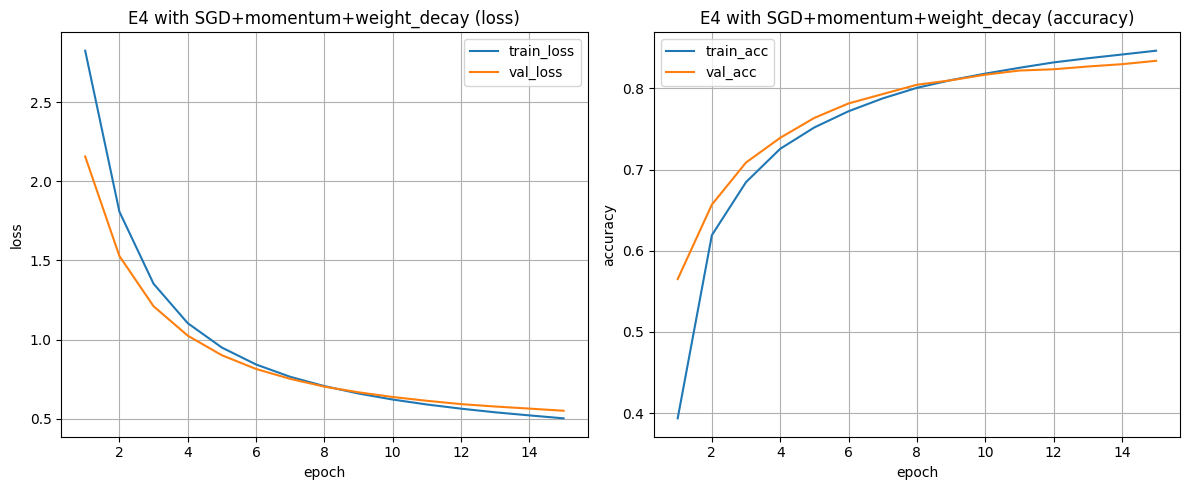

SGD+momentum+weight_decay test: loss=0.5729, acc=0.8242


In [34]:
set_seed(42)
combo_o3_model = MLP(hidden_dims=(256,128),dropout_p=0.0,use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(combo_o3_model.parameters(),lr=1e-3,momentum=0.9,weight_decay=1e-4)

es = EarlyStopping(patience=4,min_delta = 0.0005)

history_combo_o3 = fit(
    combo_o3_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=15,
    early_stopping=es,
    verbose=True
)

plot_history(history_combo_o3, title="E4 with SGD+momentum+weight_decay")
test_loss, test_acc = evaluate(combo_o3_model, test_loader, criterion, device)
print(f"SGD+momentum+weight_decay test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Сохранение артефактов

Создаем runs.csv для обобщения результатов и настроек всех экспериментов

In [35]:
runs = pd.DataFrame(columns=["experiment_id","dataset",
                             "seed","model_summary",
                             "optimizer","lr","momentum",
                             "weight_decay","epochs_trained",
                             "best_val_accuracy","best_val_loss"])
runs.loc[len(runs)] = ["E0","EMNIST",42,"(128,)/relu/0/False","Adam",1e-3,0,0,20,history_baseline["val_acc"][-1],history_baseline["val_loss"][-1]]
runs.loc[len(runs)] = ["E1","EMNIST",42,"(256,128)/relu/0/False","Adam",1e-3,0,0,20,history_baseline_improved["val_acc"][-1],history_baseline_improved["val_loss"][-1]]
runs.loc[len(runs)] = ["E2","EMNIST",42,"(256,128)/relu/0.3/False","Adam",1e-3,0,0,20,history_dropout["val_acc"][-1],history_dropout["val_loss"][-1]]
runs.loc[len(runs)] = ["E3","EMNIST",42,"(256,128)/relu/0/True","Adam",1e-3,0,0,20,history_bn["val_acc"][-1],history_bn["val_loss"][-1]]
runs.loc[len(runs)] = ["E4","EMNIST",42,"(256,128)/relu/0/True","Adam",1e-3,0,0,19,history_combo["val_acc"][-1],history_combo["val_loss"][-1]]
runs.loc[len(runs)] = ["O1","EMNIST",42,"(256,128)/relu/0/True","Adam",1e-1,0,0,8,history_combo_o1["val_acc"][-1],history_combo_o1["val_loss"][-1]]
runs.loc[len(runs)] = ["O2","EMNIST",42,"(256,128)/relu/0/True","Adam",1e-5,0,0,8,history_combo_o2["val_acc"][-1],history_combo_o2["val_loss"][-1]]
runs.loc[len(runs)] = ["O3","EMNIST",42,"(256,128)/relu/0/True","SGD",1e-3,0.9,1e-4,15,history_combo_o3["val_acc"][-1],history_combo_o3["val_loss"][-1]]


runs.to_csv("artifacts/runs.csv", index=False)

Сохраняем state_dict() лучшей модели

In [36]:
torch.save(combo_model.state_dict(), "artifacts/best_model.pt")

Сохраняем лучший конфиг

In [37]:
best_config = {
    "model":{
        "arhitecture": "MLP",
        "activation": "relu",
        "hidden_dims": (256,128),
        "dropout_p": 0.0,
        "use_batchnorm": True
    },
    "training":{
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": BATCH_SIZE,
        "epochs": 19,
        "loss_function": "CrossEntropyLoss",
        "early_stopping": {
            "patience": 4,
            "min_delta": 0.0005
        }
    },
    "dataset": "EMNIST",
    "metrics":{
        "best_val_accuracy": history_combo["val_acc"][-1],
        "best_val_loss": history_combo["val_loss"][-1],
        "test_accuracy": E4_test_acc,
        "test_loss": E4_test_loss
    },
    "seed": 42
}

with open("artifacts/best_config.json","w") as f:
    json.dump(best_config,f,indent=4)